# FILIP ECG Interactive Attention Visualizer

This notebook provides an interactive interface for visualizing patch-to-feature attention heatmaps generated by the FILIP-style ECG model. It supports both **Stage 1 (MIMIC Pretraining)** feature alignment and **Stage 2 (PTB-XL Diagnosis Adaptation)** diagnostic alignment.

Matplotlib plots are rendered inline. Features can be updated in real-time without reloading the model, which is cached in memory.

## 1. Configure Workspace Paths

Set the path to your repository root and the ECG dataset generated images folder below. The notebook will automatically append the project root to `sys.path` and change the current working directory to it so that relative checkpoint paths resolve properly.

In [1]:
import os
import sys

# Set repository root and generated images folder
PROJECT_ROOT = "/home/qfbqt/repo/GEM-fork"
IMAGE_DIR = "/home/qfbqt/8TB/datasets/ptb-xl-gen"

# Append root directory to sys.path to enable importing filip package
if os.path.exists(PROJECT_ROOT):
    if PROJECT_ROOT not in sys.path:
        sys.path.append(PROJECT_ROOT)
    os.chdir(PROJECT_ROOT)
    print(f"[SUCCESS] Changed working directory to project root: {os.getcwd()}")
else:
    print(f"[ERROR] PROJECT_ROOT path does not exist: {PROJECT_ROOT}")

[SUCCESS] Changed working directory to project root: /home/qfbqt/repo/GEM-fork


## 2. Imports and Environment Setup

Load standard scientific libraries, PIL, Matplotlib, and key model packages.

In [2]:
import glob
import json
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms

from filip.model.filip_ecg_model import FILIPECGModel
print("PyTorch version:", torch.__version__)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

/home/qfbqt/miniconda3/envs/gem/lib/python3.10/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/qfbqt/miniconda3/envs/gem/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.10.0+cu130
Device: cuda


## 3. Helper Definitions

We define the `ExpandToSquare` class (which pads non-square ECG images with white backgrounds to avoid distorting the waveforms during resizing) and configure model caching.

In [3]:
class ExpandToSquare(object):
    def __init__(self, background_color=(255, 255, 255)):
        self.background_color = background_color

    def __call__(self, img):
        width, height = img.size
        if width == height:
            return img
        elif width > height:
            result = Image.new(img.mode, (width, width), self.background_color)
            result.paste(img, (0, (width - height) // 2))
            return result
        else: 
            result = Image.new(img.mode, (height, height), self.background_color)
            result.paste(img, ((height - width) // 2, 0))
            return result

# Global caching system to keep the 1GB model weights loaded in memory
cached_model = None
cached_checkpoint_path = None

## 4. Visualization Core Code

We define helper functions to load checkpoints and project intermediate feature-to-patch similarity to diagnosis-to-patch alignments.

In [4]:
def load_model_cached(checkpoint_path, device):
    global cached_model, cached_checkpoint_path
    
    if cached_model is None or cached_checkpoint_path != checkpoint_path:
        print(f"[INFO] Loading model checkpoint from: {checkpoint_path}...")
        checkpoint = torch.load(checkpoint_path, map_location=device)
        config = checkpoint.get("config")
        if config is None:
            raise ValueError("Checkpoint does not contain 'config' configuration dictionary.")
            
        model = FILIPECGModel(config).to(device)
        state_dict = checkpoint["model_state_dict"]
        model_state_dict = model.state_dict()
        filtered_state_dict = {}
        for k, v in state_dict.items():
            if k in model_state_dict and v.shape == model_state_dict[k].shape:
                filtered_state_dict[k] = v
        model.load_state_dict(filtered_state_dict, strict=False)
        model.eval()
        
        is_stage2 = "diagnosis_vocab" in checkpoint
        vocab = checkpoint["diagnosis_vocab"] if is_stage2 else checkpoint.get("feature_vocab", {})
        vocab_list = list(vocab.keys()) if isinstance(vocab, dict) else list(vocab)
        if not vocab_list:
            from filip.data.vocab import MIMIC_FEATURES, PTBXL_SUPERCLASSES
            vocab_list = PTBXL_SUPERCLASSES if is_stage2 else MIMIC_FEATURES
            
        cached_model = (model, vocab_list, is_stage2, config)
        cached_checkpoint_path = checkpoint_path
    
    return cached_model

def get_projected_similarity(model, similarity, is_stage2, vocab_list, target_class):
    """
    Projects intermediate feature similarities to diagnosis classes using the diagnosis head weights.
    """
    if is_stage2 and target_class in vocab_list:
        feat_idx = vocab_list.index(target_class)
        diag_weight = model.diagnosis_head.weight # [5, 20]
        # Project: similarity [1, 49, 20] @ diag_weight.T [20, 5] -> [1, 49, 5]
        # Call .detach() to prevent gradient tracking on variables passed to numpy
        patch_diagnosis_similarity = torch.matmul(similarity, diag_weight.t()).detach()
        return patch_diagnosis_similarity[0, :, feat_idx].cpu().numpy()
    else:
        # If Stage 1, or looking at raw intermediate features in Stage 2
        from filip.data.vocab import MIMIC_FEATURES
        if target_class in vocab_list:
            feat_idx = vocab_list.index(target_class)
        elif target_class in MIMIC_FEATURES:
            feat_idx = MIMIC_FEATURES.index(target_class)
        else:
            raise ValueError(f"Class '{target_class}' not found in vocabulary.")
            
        return similarity[0, :, feat_idx].detach().cpu().numpy()

## 5. Single Feature/Class Visualization

Generates a side-by-side plot of the original ECG and the target class heatmap (with proper feature-to-patch projection for Stage 2 diagnosis classes).

In [5]:
def visualize_attention(checkpoint_path, image_path, feature_name):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model, vocab_list, is_stage2, config = load_model_cached(checkpoint_path, device)
    vocab_type = "diagnosis" if is_stage2 else "feature"
    
    # If no feature specified, display choices
    if feature_name is None:
        print(f"Available classes in checkpoint ({vocab_type}): {vocab_list}")
        if is_stage2:
            from filip.data.vocab import MIMIC_FEATURES
            print(f"Intermediate MIMIC features available: {MIMIC_FEATURES}")
        return vocab_list
        
    # 1. Image preprocessing
    original_image = Image.open(image_path).convert("RGB")
    transform = transforms.Compose([
        ExpandToSquare(background_color=(255, 255, 255)),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.48145466, 0.4578275, 0.40821073],
            std=[0.26862954, 0.26130258, 0.27577711]
        )
    ])
    input_tensor = transform(original_image).unsqueeze(0).to(device)

    # 2. Model Inference
    with torch.no_grad():
        outputs = model(input_tensor)
        
    similarity = outputs.get("patch_feature_similarity")  # [1, 49, 20]
    if similarity is None:
        raise ValueError("Model did not return 'patch_feature_similarity'.")
        
    # Get correct similarity scores (projecting if diagnosis class)
    sim_scores = get_projected_similarity(model, similarity, is_stage2, vocab_list, feature_name)
    sim_grid = sim_scores.reshape(7, 7)
    
    # Normalize grid to [0, 1] range
    sim_min, sim_max = sim_grid.min(), sim_grid.max()
    sim_range = (sim_max - sim_min) if (sim_max - sim_min) > 1e-5 else 1.0
    sim_grid_norm = (sim_grid - sim_min) / sim_range
    
    # 3. Generate Heatmap overlay
    heatmap_pil = Image.fromarray((sim_grid_norm * 255).astype(np.uint8))
    heatmap_pil = heatmap_pil.resize(original_image.size, Image.Resampling.BICUBIC)
    
    colormap = plt.colormaps.get_cmap("jet")
    heatmap_color = colormap(np.array(heatmap_pil) / 255.0)
    heatmap_color_rgb = (heatmap_color[:, :, :3] * 255).astype(np.uint8)
    heatmap_color_pil = Image.fromarray(heatmap_color_rgb)
    blended_image = Image.blend(original_image, heatmap_color_pil, alpha=0.35)
    
    # 4. Plot results
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    axes[0].imshow(original_image)
    axes[0].set_title(f"Original ECG Image: {os.path.basename(image_path)}", fontsize=12, fontweight="bold")
    axes[0].axis("off")
    
    axes[1].imshow(blended_image)
    is_projected = is_stage2 and feature_name in vocab_list
    title_suffix = "(Projected Diagnosis)" if is_projected else "(Raw Feature)"
    axes[1].set_title(f"Heatmap: {feature_name} {title_suffix}", fontsize=12, fontweight="bold")
    axes[1].axis("off")
    
    sm = plt.cm.ScalarMappable(cmap=colormap, norm=plt.Normalize(vmin=sim_min, vmax=sim_max))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes[1], orientation="vertical", shrink=0.7)
    cbar.set_label("Similarity Score", fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # Save file
    exp_name = config.get("task", "pretrain")
    out_dir = f"outputs/filip/{exp_name}/notebook_visualizations"
    os.makedirs(out_dir, exist_ok=True)
    img_id = os.path.splitext(os.path.basename(image_path))[0]
    out_png = os.path.join(out_dir, f"{img_id}_{feature_name}.png")
    fig.savefig(out_png, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved visual figure to: {out_png}")

## 6. Combined 5-Class Grid Visualization

Plots the original ECG alongside the heatmaps for all 5 PTB-XL diagnosis classes (`NORM`, `MI`, `HYP`, `CD`, `STTC`) in a 2x3 grid, projecting the intermediate features onto the patches using the classification weights.

In [6]:
def visualize_all_diagnoses(checkpoint_path, image_path):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model, vocab_list, is_stage2, config = load_model_cached(checkpoint_path, device)
    
    if not is_stage2:
        print("[ERROR] This checkpoint is a Stage 1 pretrain model. No diagnosis classes available.")
        return
        
    # 1. Image preprocessing
    original_image = Image.open(image_path).convert("RGB")
    transform = transforms.Compose([
        ExpandToSquare(background_color=(255, 255, 255)),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.48145466, 0.4578275, 0.40821073],
            std=[0.26862954, 0.26130258, 0.27577711]
        )
    ])
    input_tensor = transform(original_image).unsqueeze(0).to(device)
    
    # 2. Model Inference
    with torch.no_grad():
        outputs = model(input_tensor)
        
    similarity = outputs.get("patch_feature_similarity")  # [1, 49, 20]
    if similarity is None:
        raise ValueError("Model did not return 'patch_feature_similarity'.")
        
    # Project intermediate feature similarities to diagnosis classes
    diag_weight = model.diagnosis_head.weight # [5, 20]
    # Call .detach() to prevent gradient tracking on variables passed to numpy
    patch_diagnosis_similarity = torch.matmul(similarity, diag_weight.t()).detach() # [1, 49, 5]
    
    # 3. Setup 2x3 Grid Plot
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    # Plot 1: Original ECG image
    axes[0].imshow(original_image)
    axes[0].set_title(f"Original ECG\n{os.path.basename(image_path)}", fontsize=14, fontweight="bold")
    axes[0].axis("off")
    
    colormap = plt.colormaps.get_cmap("jet")
    
    # Plot 2-6: Diagnoses heatmaps
    for i, diag_class in enumerate(vocab_list):
        ax = axes[i + 1]
        
        sim_scores = patch_diagnosis_similarity[0, :, i].cpu().numpy()
        sim_grid = sim_scores.reshape(7, 7)
        
        # Normalize grid
        sim_min, sim_max = sim_grid.min(), sim_grid.max()
        sim_range = (sim_max - sim_min) if (sim_max - sim_min) > 1e-5 else 1.0
        sim_grid_norm = (sim_grid - sim_min) / sim_range
        
        # Overlay heatmap
        heatmap_pil = Image.fromarray((sim_grid_norm * 255).astype(np.uint8))
        heatmap_pil = heatmap_pil.resize(original_image.size, Image.Resampling.BICUBIC)
        
        heatmap_color = colormap(np.array(heatmap_pil) / 255.0)
        heatmap_color_rgb = (heatmap_color[:, :, :3] * 255).astype(np.uint8)
        heatmap_color_pil = Image.fromarray(heatmap_color_rgb)
        blended_image = Image.blend(original_image, heatmap_color_pil, alpha=0.35)
        
        ax.imshow(blended_image)
        ax.set_title(f"Heatmap: {diag_class} (Projected)", fontsize=14, fontweight="bold")
        ax.axis("off")
        
        sm = plt.cm.ScalarMappable(cmap=colormap, norm=plt.Normalize(vmin=sim_min, vmax=sim_max))
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, orientation="horizontal", pad=0.08, shrink=0.75)
        cbar.set_label("Similarity Score", fontsize=10)
        
    plt.tight_layout()
    plt.show()
    
    # Save figure
    exp_name = config.get("task", "pretrain")
    out_dir = f"outputs/filip/{exp_name}/notebook_visualizations"
    os.makedirs(out_dir, exist_ok=True)
    img_id = os.path.splitext(os.path.basename(image_path))[0]
    out_png = os.path.join(out_dir, f"{img_id}_all_diagnoses.png")
    fig.savefig(out_png, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved full 5-class visual figure to: {out_png}")

## 7. Manual Run

Configure variables here to manually invoke either visualizer.

--- Visualizing All 5 Diagnosis Classes ---
[INFO] Loading model checkpoint from: outputs/filip/ptbxl_diagnosis_adapt/checkpoints/best.pt...


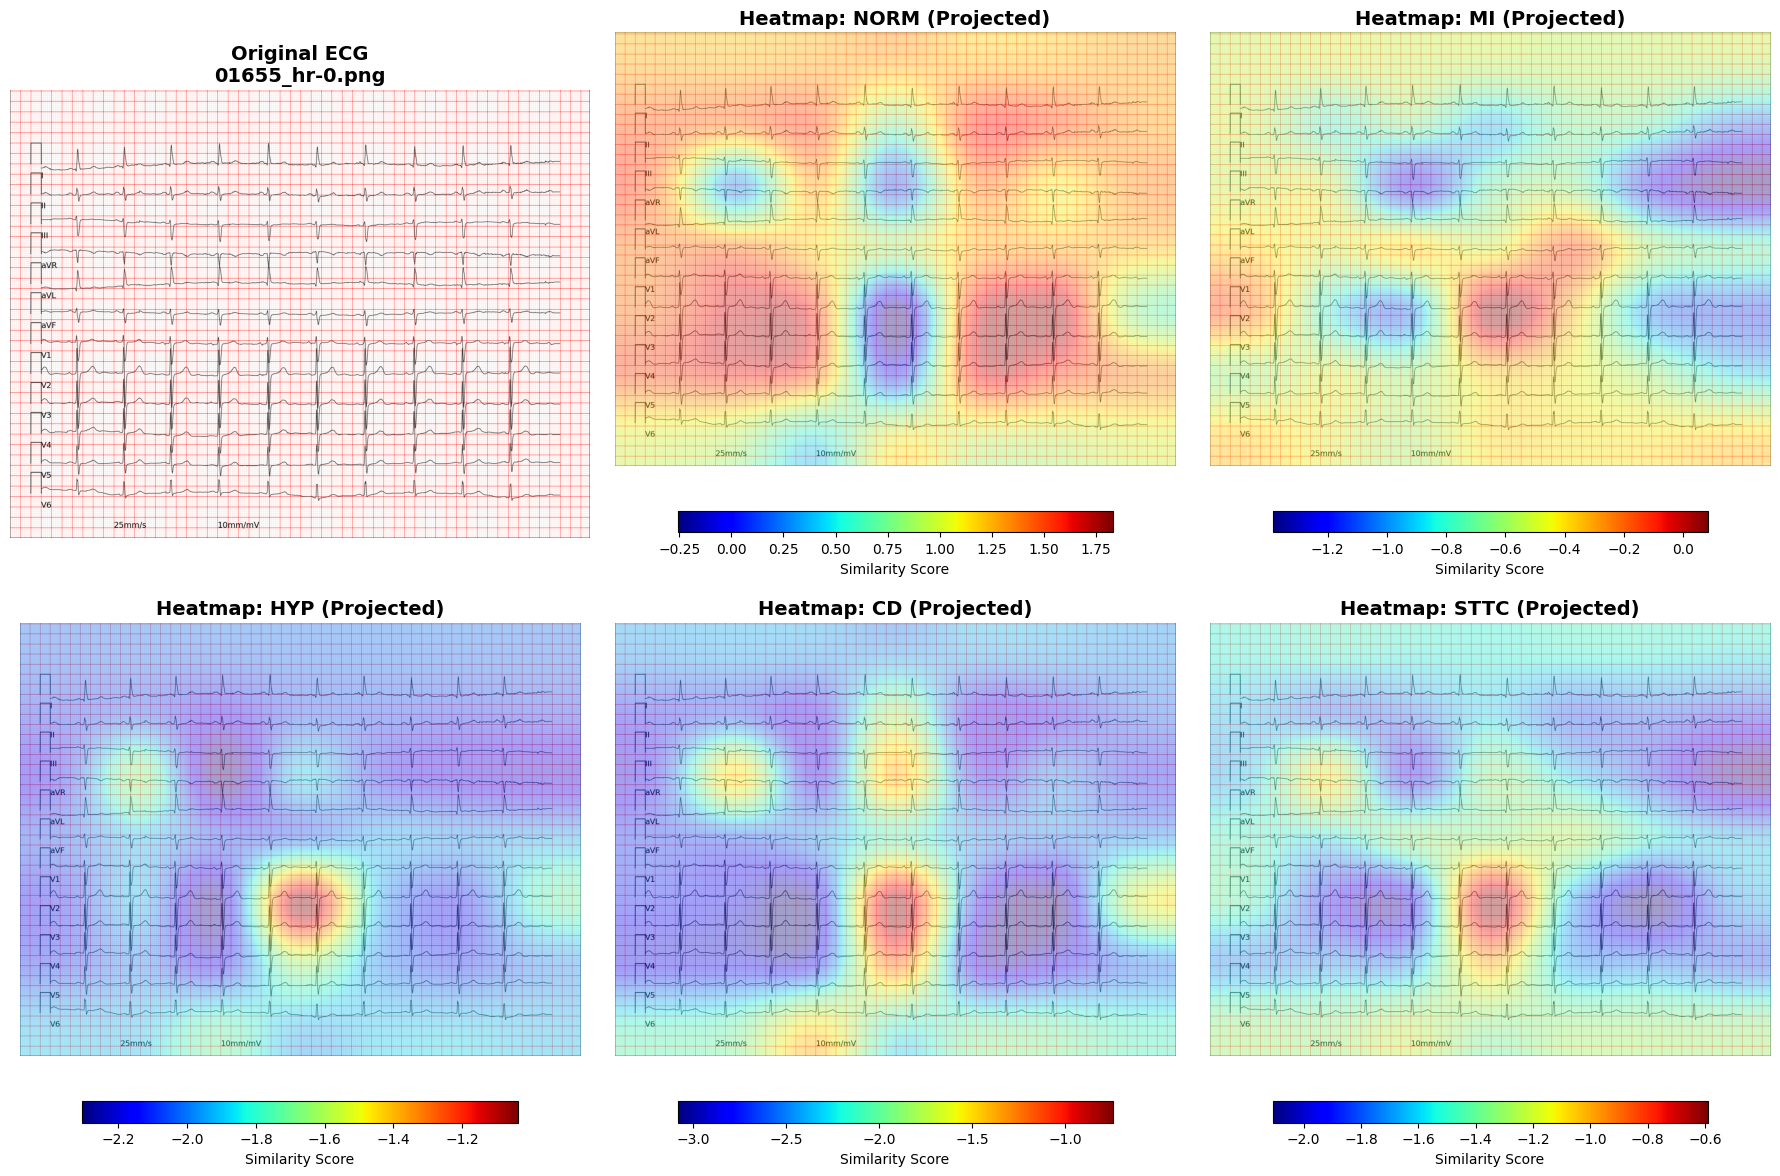

Saved full 5-class visual figure to: outputs/filip/diagnosis_adapt/notebook_visualizations/01655_hr-0_all_diagnoses.png

--- Visualizing Single Feature: atrial_fibrillation (MIMIC Intermediate Feature) ---


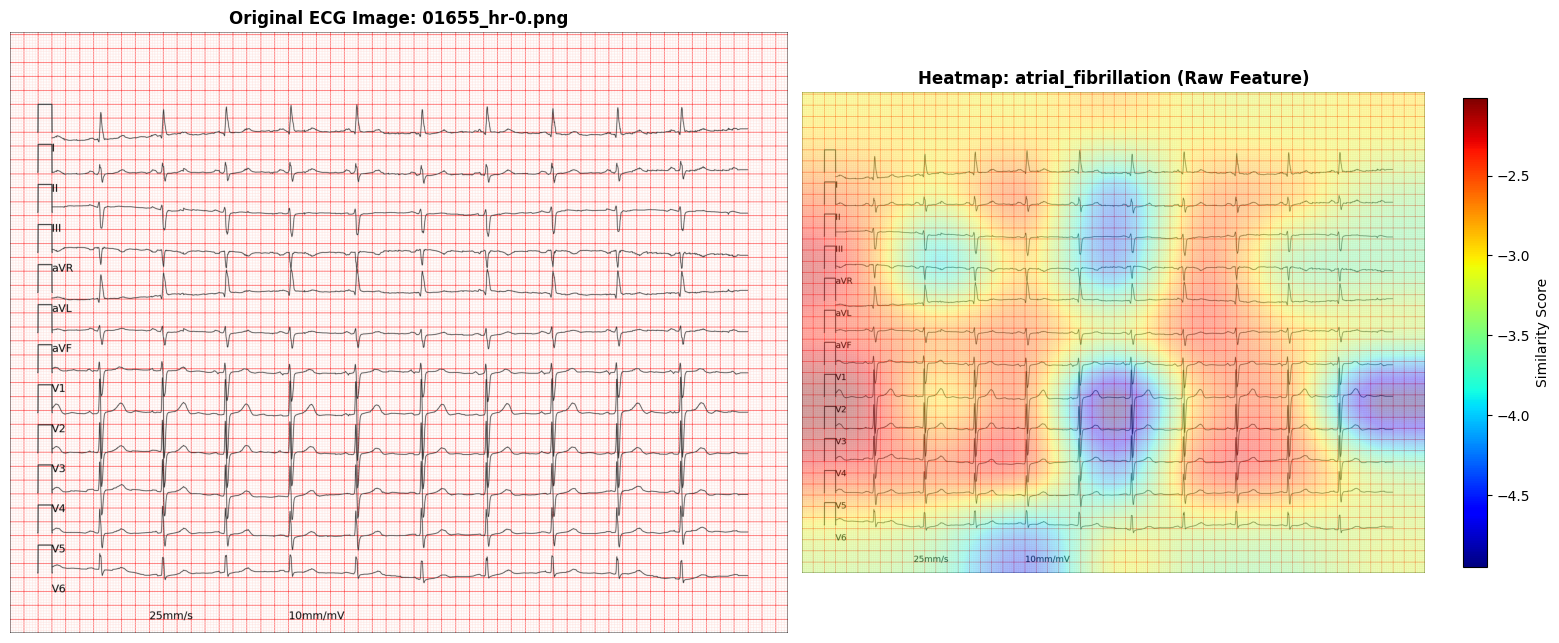

Saved visual figure to: outputs/filip/diagnosis_adapt/notebook_visualizations/01655_hr-0_atrial_fibrillation.png


In [ ]:
CHECKPOINT = "outputs/filip/ptbxl_diagnosis_adapt/checkpoints/best.pt"
IMAGE = os.path.join(IMAGE_DIR, "01655_hr-0.png")

if os.path.exists(CHECKPOINT) and os.path.exists(IMAGE):
    # 1. Visualize all 5 classes together in a grid (Projected)
    print("--- Visualizing All 5 Diagnosis Classes ---")
    visualize_all_diagnoses(CHECKPOINT, IMAGE)
    
    # 2. Visualize a single class or intermediate MIMIC feature
    print("\n--- Visualizing Single Feature: atrial_fibrillation (MIMIC Intermediate Feature) ---")
    visualize_attention(CHECKPOINT, IMAGE, "atrial_fibrillation")
else:
    print(f"Verify paths exist:\nCheckpoint: {os.path.exists(CHECKPOINT)}\nImage: {os.path.exists(IMAGE)}")

## 8. Interactive UI Widgets (Jupyter & VS Code)

Run this cell to render drop-downs. Select "All 5 Diagnoses Grid" or select a single intermediate/diagnosis class to plot.

In [8]:
try:
    import ipywidgets as widgets
    from ipywidgets import interact
    
    checkpoints = sorted(glob.glob("outputs/**/*.pt", recursive=True))
    images = []
    if os.path.exists(IMAGE_DIR):
        images = sorted([os.path.join(IMAGE_DIR, f) for f in os.listdir(IMAGE_DIR) if f.endswith(".png")])[:30]
        
    if not checkpoints:
        print("No checkpoint files found in outputs/.")
    elif not images:
        print(f"No image files found in {IMAGE_DIR}.")
    else:
        chk_dropdown = widgets.Dropdown(options=checkpoints, description="Checkpoint:")
        img_dropdown = widgets.Dropdown(options=images, description="ECG Image:")
        mode_dropdown = widgets.Dropdown(options=["All 5 Diagnoses Grid", "Single Class/Feature"], description="Mode:")
        feat_dropdown = widgets.Dropdown(options=[], description="Feature/Class:")
        
        def update_vocab(*args):
            try:
                checkpoint = torch.load(chk_dropdown.value, map_location="cpu")
                is_stage2 = "diagnosis_vocab" in checkpoint
                vocab = checkpoint["diagnosis_vocab"] if is_stage2 else checkpoint.get("feature_vocab", {})
                vocab_list = list(vocab.keys()) if isinstance(vocab, dict) else list(vocab)
                if not vocab_list:
                    from filip.data.vocab import MIMIC_FEATURES, PTBXL_SUPERCLASSES
                    vocab_list = PTBXL_SUPERCLASSES if is_stage2 else MIMIC_FEATURES
                
                # For Stage 2, allow selecting diagnosis classes OR intermediate features
                if is_stage2:
                    from filip.data.vocab import MIMIC_FEATURES
                    feat_dropdown.options = vocab_list + ["-- Intermediate Features --"] + MIMIC_FEATURES
                else:
                    feat_dropdown.options = vocab_list
            except Exception as e:
                print("Error reading vocabulary:", e)
                
        chk_dropdown.observe(update_vocab, 'value')
        update_vocab()
        
        # Toggle feature dropdown depending on selected mode
        def toggle_dropdowns(*args):
            if mode_dropdown.value == "All 5 Diagnoses Grid":
                feat_dropdown.layout.display = 'none'
            else:
                feat_dropdown.layout.display = 'block'
        mode_dropdown.observe(toggle_dropdowns, 'value')
        toggle_dropdowns()
        
        @interact(checkpoint=chk_dropdown, image=img_dropdown, mode=mode_dropdown, feature=feat_dropdown)
        def run_interactive(checkpoint, image, mode, feature):
            if checkpoint and image:
                checkpoint_data = torch.load(checkpoint, map_location="cpu")
                is_stage2 = "diagnosis_vocab" in checkpoint_data
                
                if mode == "All 5 Diagnoses Grid":
                    if is_stage2:
                        visualize_all_diagnoses(checkpoint, image)
                    else:
                        print("[ERROR] This pretrain checkpoint does not support diagnosis classes. Select 'Single Class/Feature' instead.")
                else:
                    if feature and not feature.startswith("--"):
                        visualize_attention(checkpoint, image, feature)
except ImportError:
    print("The 'ipywidgets' library is not installed in the environment.")
    print("Please install it using: conda install ipywidgets -n gem  (or pip install ipywidgets)")
    print("Or use the manual cell in Section 7 above.")

The 'ipywidgets' library is not installed in the environment.
Please install it using: conda install ipywidgets -n gem  (or pip install ipywidgets)
Or use the manual cell in Section 7 above.
